# Beam partial-Cholesky projection enclosure (v7)

This notebook implements the stated partial-Cholesky algorithm for `system_beam`. For every requested `m`, `A[:m, :m]` is extracted as a sparse leading principal block and converted directly to lower-banded storage before calling `scipy.linalg.cholesky_banded`. No full factor is truncated, no projector is formed, and the factor for a given block is reused by `cho_solve_banded`.

The first cell below also checks the **original supplied physical box** against an independently solved reference before the experiment. The supplied box does not contain the reference solution, so this notebook explicitly chooses the same endpoint-wise effective-box correction used by `system_beam_to_completion.ipynb`: only violating endpoints are moved to the reference solution. Shrinkage is measured from this effective initial box after mapping all bounds back to the original, unscaled physical coordinates. The supplied box and its containment diagnostics are retained in the saved results.

In [1]:
from pathlib import Path
import gc
import pickle
import time

from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from scipy.linalg import cholesky_banded, cho_solve_banded
from scipy.sparse import csr_matrix, diags

results_dir = Path("system_beam_solver_v7_results")
results_dir.mkdir(exist_ok=True)


## Load, scale, and audit the supplied box

As in `system_beam_to_completion.ipynb`, the first three constrained degrees of freedom are removed and Jacobi scaling is applied with `D = sqrt(diag(A))`. The scaled variables satisfy `y = D x`, `A_hat = D^{-1} A D^{-1}`, and `b_hat = D^{-1} b`.

The full-size factor computed here is the requested `m=n` factor. It is retained and reused when the sweep reaches `m=n`; smaller factors are still computed directly from their own leading blocks.

In [2]:
with Path("wing_bsm_30k.pkl").open("rb") as file:
    K_full, F_full, U_full, B0_1_full, B0_2_full = pickle.load(file)

A_full = csr_matrix(K_full)
A = A_full[3:, 3:].tocsr()
b = np.asarray(F_full[3:], dtype=float).copy()
stored_solution = np.asarray(U_full[3:], dtype=float).copy()
supplied_box = np.asarray(B0_1_full[3:], dtype=float).copy()
if not np.array_equal(B0_1_full[3:], B0_2_full[3:]):
    raise ValueError("The two supplied beam boxes differ after removing BC coordinates.")

del K_full, F_full, U_full, B0_1_full, B0_2_full, A_full
gc.collect()

n = b.size
diagonal = A.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = (diags(inverse_scale) @ A @ diags(inverse_scale)).tocsr()
b_hat = inverse_scale * b

rows, columns = A_hat.nonzero()
bandwidth = int(np.max(np.abs(rows - columns)))
del rows, columns

def leading_principal_banded(m):
    """Return only sparse A_hat[:m,:m], packed in lower-banded storage."""
    if not 1 <= m <= n:
        raise ValueError(f"m must lie in [1, {n}], got {m}.")
    A11 = A_hat[:m, :m]  # sparse; never densified
    ab = np.zeros((bandwidth + 1, m), dtype=float, order="F")
    for offset in range(bandwidth + 1):
        length = m - offset
        if length > 0:
            ab[offset, :length] = A11.diagonal(-offset)
    return ab

# This is the requested m=n factor, computed from its own n-by-n block.
full_banded = leading_principal_banded(n)
full_factor_start = time.perf_counter()
full_factor = cholesky_banded(full_banded, lower=True, check_finite=False)
full_factorization_seconds = time.perf_counter() - full_factor_start
reference_y = cho_solve_banded(
    (full_factor, True), b_hat, overwrite_b=False, check_finite=False
)
reference_x = inverse_scale * reference_y

reference_residual = A @ reference_x - b
relative_residual = np.linalg.norm(reference_residual) / np.linalg.norm(b)
A_infinity_norm = np.asarray(np.abs(A).sum(axis=1)).ravel().max()
normwise_backward_error = np.linalg.norm(reference_residual, ord=np.inf) / (
    A_infinity_norm * np.linalg.norm(reference_x, ord=np.inf) + np.linalg.norm(b, ord=np.inf)
)
componentwise_denominator = np.abs(A) @ np.abs(reference_x) + np.abs(b)
componentwise_backward_error = np.max(
    np.divide(
        np.abs(reference_residual), componentwise_denominator,
        out=np.zeros_like(reference_residual), where=componentwise_denominator > 0.0,
    )
)
stored_difference = np.max(np.abs(stored_solution - reference_x))
outside_original_box = (reference_x < supplied_box[:, 0]) | (reference_x > supplied_box[:, 1])
original_box_contains_reference = not np.any(outside_original_box)
lower_violation = np.maximum(supplied_box[:, 0] - reference_x, 0.0)
upper_violation = np.maximum(reference_x - supplied_box[:, 1], 0.0)
max_endpoint_violation = max(lower_violation.max(), upper_violation.max())

print(f"system dimension n: {n:,}")
print(f"scaled half-bandwidth: {bandwidth}")
print(f"reference relative residual (cancellation-sensitive): {relative_residual:.3e}")
print(f"reference normwise backward error: {normwise_backward_error:.3e}")
print(f"reference componentwise backward error: {componentwise_backward_error:.3e}")
print(f"max |stored solution - solved reference|: {stored_difference:.3e}")
print("Original supplied box contains the reference solution: "
      + ("YES" if original_box_contains_reference else "NO"))
print(f"coordinates outside the supplied box: {outside_original_box.sum():,} / {n:,}")
print(f"largest endpoint violation in physical units: {max_endpoint_violation:.6e}")

if original_box_contains_reference:
    effective_box = supplied_box.copy()
    correction_message = "No correction was needed."
else:
    effective_box = np.column_stack([
        np.minimum(supplied_box[:, 0], reference_x),
        np.maximum(supplied_box[:, 1], reference_x),
    ])
    correction_message = (
        "Using the same effective-box correction as system_beam_to_completion.ipynb: "
        "each violating endpoint is expanded exactly to the solved reference."
    )
print(correction_message)

# Guard the scaled endpoints against a one-ulp round-trip exclusion of reference_y.
# This is only a floating-point representation safeguard for the chosen physical box.
lower0 = np.minimum(scale * effective_box[:, 0], reference_y)
upper0 = np.maximum(scale * effective_box[:, 1], reference_y)
initial_width_physical = inverse_scale * (upper0 - lower0)
if np.any(initial_width_physical <= 0.0):
    raise ValueError("Every effective initial-box width must be positive.")
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)


system dimension n: 30,000
scaled half-bandwidth: 4
reference relative residual (cancellation-sensitive): 1.656e-01
reference normwise backward error: 1.490e-17
reference componentwise backward error: 4.471e-16
max |stored solution - solved reference|: 2.431e-01
Original supplied box contains the reference solution: NO
coordinates outside the supplied box: 3,334 / 30,000
largest endpoint violation in physical units: 2.110169e+00
Using the same effective-box correction as system_beam_to_completion.ipynb: each violating endpoint is expanded exactly to the solved reference.


## Direct partial-Cholesky enclosure

For `m<n`, a banded matrix with half-bandwidth `w` has nonzeros in `A12` only in its first `min(w, n-m)` columns. The implementation stores precisely those boundary columns. Solving against them is algebraically identical to solving against a full zero-padded `A12`, while avoiding an `m` by `(n-m)` dense array.

In [3]:
def partial_cholesky_enclosure(m, factor):
    """Apply the stated algorithm using an already computed factor of A11."""
    projected_center = np.empty(n, dtype=float)
    projected_radius = np.empty(n, dtype=float)

    if m < n:
        boundary_count = min(bandwidth, n - m)
        if A_hat[:m, m + boundary_count:].nnz != 0:
            raise AssertionError("A12 has nonzeros beyond the stored boundary columns.")

        # Only these boundary columns can be nonzero. A11 itself stays sparse/banded.
        A12_boundary = A_hat[:m, m:m + boundary_count].toarray()
        C_boundary = cho_solve_banded(
            (factor, True), A12_boundary, overwrite_b=False, check_finite=False
        )
        center_rhs = b_hat[:m] - A12_boundary @ center0[m:m + boundary_count]
        projected_center[:m] = cho_solve_banded(
            (factor, True), center_rhs, overwrite_b=False, check_finite=False
        )
        projected_center[m:] = center0[m:]
        projected_radius[:m] = np.abs(C_boundary) @ radius0[m:m + boundary_count]
        projected_radius[m:] = radius0[m:]
    else:
        # The stated formulas reduce to A^{-1}b and zero radius when the tail is empty.
        projected_center[:] = cho_solve_banded(
            (factor, True), b_hat, overwrite_b=False, check_finite=False
        )
        projected_radius.fill(0.0)

    lower = np.maximum(lower0, projected_center - projected_radius)
    upper = np.minimum(upper0, projected_center + projected_radius)
    if np.any(lower > upper):
        worst_gap = np.max(lower - upper)
        raise RuntimeError(f"Empty coordinate intersection; largest gap={worst_gap:.3e}.")
    return lower, upper


## Sweep, validation, and raw results

The sweep uses `m=1000, 2000, ...` and always appends `n` if needed. The width ratio is calculated only after unscaling each enclosure to physical coordinates. Enclosure containment is checked at every `m`, and the `m=n` result must have approximately 100% shrinkage in every coordinate.

In [4]:
m_values = np.arange(1000, n + 1, 1000, dtype=int)
if m_values.size == 0 or m_values[-1] != n:
    m_values = np.append(m_values, n)
m_values = np.unique(m_values)

coordinate_shrinkage_pct = np.empty((m_values.size, n), dtype=float)
mean_shrinkage_pct = np.empty(m_values.size, dtype=float)
factorization_seconds = np.empty(m_values.size, dtype=float)
enclosure_seconds = np.empty(m_values.size, dtype=float)
reference_tolerance = 5e-10 * np.maximum(1.0, np.abs(reference_y))

print("m       mean shrinkage    factor (s)    enclosure (s)")
for index, m in enumerate(m_values):
    m = int(m)
    factor_start = time.perf_counter()
    if m == n:
        factor = full_factor  # reuse the m=n factor already computed above
        factorization_seconds[index] = full_factorization_seconds
    else:
        block_banded = leading_principal_banded(m)
        factor = cholesky_banded(
            block_banded, lower=True, overwrite_ab=True, check_finite=False
        )
        factorization_seconds[index] = time.perf_counter() - factor_start

    enclosure_start = time.perf_counter()
    lower_scaled, upper_scaled = partial_cholesky_enclosure(m, factor)
    enclosure_seconds[index] = time.perf_counter() - enclosure_start

    if np.any(reference_y < lower_scaled - reference_tolerance) or \
       np.any(reference_y > upper_scaled + reference_tolerance):
        raise AssertionError(f"The m={m} enclosure misses the reference solution.")

    lower_physical = inverse_scale * lower_scaled
    upper_physical = inverse_scale * upper_scaled
    raw_shrinkage = 100.0 * (
        1.0 - (upper_physical - lower_physical) / initial_width_physical
    )
    if raw_shrinkage.min() < -1e-8 or raw_shrinkage.max() > 100.0 + 1e-8:
        raise AssertionError(f"Unexpected shrinkage range at m={m}.")
    coordinate_shrinkage_pct[index] = np.clip(raw_shrinkage, 0.0, 100.0)
    mean_shrinkage_pct[index] = coordinate_shrinkage_pct[index].mean()
    print(
        f"{m:5d}      {mean_shrinkage_pct[index]:9.4f}%"
        f"      {factorization_seconds[index]:8.4f}      {enclosure_seconds[index]:8.4f}"
    )
    del factor, lower_scaled, upper_scaled, lower_physical, upper_physical
    gc.collect()

np.testing.assert_allclose(
    coordinate_shrinkage_pct[-1], 100.0, rtol=0.0, atol=1e-8,
    err_msg="At m=n, every coordinate must have approximately 100% shrinkage.",
)
print("Validated: m=n collapses every coordinate to the unique solution (approximately 100% shrinkage).")

results_path = results_dir / "partial_cholesky_shrinkage_results.npz"
np.savez_compressed(
    results_path,
    n=n,
    bandwidth=bandwidth,
    m_values=m_values,
    coordinate_shrinkage_pct=coordinate_shrinkage_pct,
    mean_shrinkage_pct=mean_shrinkage_pct,
    factorization_seconds=factorization_seconds,
    enclosure_seconds=enclosure_seconds,
    supplied_box=supplied_box,
    effective_box=effective_box,
    initial_width_physical=initial_width_physical,
    reference_solution_physical=reference_x,
    original_box_contains_reference=original_box_contains_reference,
    outside_original_box=outside_original_box,
    max_endpoint_violation=max_endpoint_violation,
    reference_relative_residual=relative_residual,
    reference_normwise_backward_error=normwise_backward_error,
    reference_componentwise_backward_error=componentwise_backward_error,
)
print(f"saved {results_path}")


m       mean shrinkage    factor (s)    enclosure (s)
 1000         1.1073%        0.0002        0.0003
 2000         2.2079%        0.0001        0.0002
 3000         3.3644%        0.0001        0.0003
 4000         4.7962%        0.0003        0.0008
 5000         6.4031%        0.0002        0.0005
 6000         8.0137%        0.0002        0.0005
 7000         9.5972%        0.0003        0.0006
 8000        11.1574%        0.0003        0.0006
 9000        12.7130%        0.0003        0.0007
10000         0.8345%        0.0003        0.0007
11000         1.0961%        0.0004        0.0008
12000         1.6739%        0.0004        0.0008
13000         2.4870%        0.0004        0.0009
14000         3.4782%        0.0005        0.0009
15000         4.6219%        0.0005        0.0011
16000         8.0064%        0.0005        0.0010
17000         9.5921%        0.0006        0.0012
18000        11.1189%        0.0007        0.0012
19000        12.7752%        0.0006        0.0

21000        50.9000%        0.0008        0.0014
22000        52.1305%        0.0007        0.0015
23000        53.5421%        0.0007        0.0016
24000        55.0851%        0.0008        0.0016
25000        56.6477%        0.0009        0.0016
26000        58.1408%        0.0008        0.0019
27000        59.6005%        0.0009        0.0017
28000        61.0185%        0.0010        0.0018
29000        62.4042%        0.0010        0.0020
30000       100.0000%        0.0004        0.0004
Validated: m=n collapses every coordinate to the unique solution (approximately 100% shrinkage).
saved system_beam_solver_v7_results/partial_cholesky_shrinkage_results.npz


## Mean shrinkage versus partial-factor size

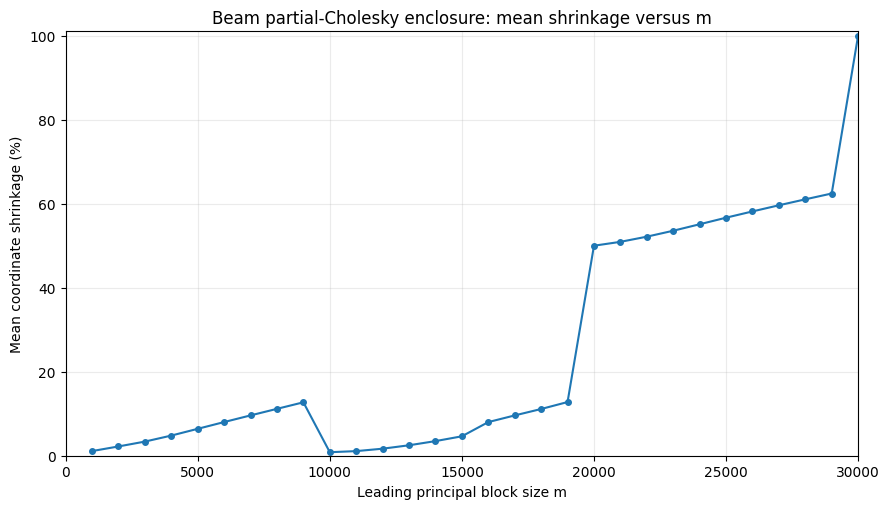

saved system_beam_solver_v7_results/mean_shrinkage_vs_m.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(m_values, mean_shrinkage_pct, color="tab:blue", marker="o", markersize=4)
ax.set(
    xlabel="Leading principal block size m",
    ylabel="Mean coordinate shrinkage (%)",
    title="Beam partial-Cholesky enclosure: mean shrinkage versus m",
    xlim=(0, n),
    ylim=(0, 101),
)
ax.grid(alpha=0.25)
fig.tight_layout()
mean_plot_path = results_dir / "mean_shrinkage_vs_m.png"
fig.savefig(mean_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {mean_plot_path}")


## Histogram animation

All frames use the same 40 bins on `[0%, 100%]`, a fixed x-axis, and a common y-axis determined across the complete animation.

saved system_beam_solver_v7_results/coordinate_shrinkage_histogram.gif


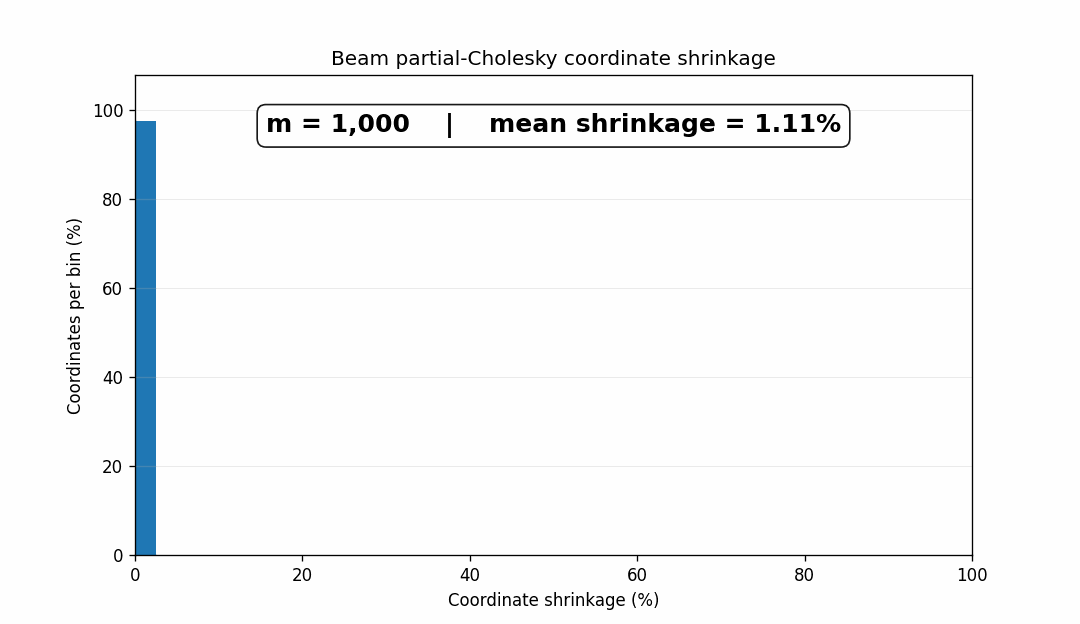

In [6]:
histogram_edges = np.linspace(0.0, 100.0, 41)
histogram_pct = np.vstack([
    100.0 * np.histogram(values, bins=histogram_edges)[0] / n
    for values in coordinate_shrinkage_pct
])
common_ymax = max(1.0, 1.08 * histogram_pct.max())

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(
    histogram_edges[:-1], histogram_pct[0], width=np.diff(histogram_edges),
    align="edge", color="tab:blue", edgecolor="white", linewidth=0.5,
)
frame_label = ax.text(
    0.5, 0.92, "", transform=ax.transAxes, ha="center", va="top",
    fontsize=15, fontweight="bold",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.9},
)
ax.set(
    xlim=(0.0, 100.0), ylim=(0.0, common_ymax),
    xlabel="Coordinate shrinkage (%)",
    ylabel="Coordinates per bin (%)",
    title="Beam partial-Cholesky coordinate shrinkage",
)
ax.grid(axis="y", alpha=0.25)

def update_histogram(frame):
    for bar, height in zip(bars, histogram_pct[frame]):
        bar.set_height(height)
    frame_label.set_text(
        f"m = {m_values[frame]:,}    |    mean shrinkage = {mean_shrinkage_pct[frame]:.2f}%"
    )
    return (*bars, frame_label)

animation = FuncAnimation(
    fig, update_histogram, frames=m_values.size, interval=350, blit=False, repeat=True
)
animation_path = results_dir / "coordinate_shrinkage_histogram.gif"
animation.save(animation_path, writer=PillowWriter(fps=3), dpi=120)
plt.close(fig)
print(f"saved {animation_path}")
display(Image(filename=str(animation_path)))
